In [ ]:
import jax.numpy as jnp
from jax.scipy import linalg
from jax import random
import matplotlib.pyplot as plt

from lqg.tracking import BoundedActor
from lqg import xcorr, LQG, Dynamics, Actor, System

## Parameters that are consistent regardless of frequency

In [ ]:
from scipy.linalg import expm, logm

# TODO: simply use standard scipy function for matrix logarithm instead of jax
# TODO: adapt to my parameterization using cholesky factors for noise covariances
def discrete_to_continuous_lqg(
    A_d, B_d, Q_d, R_d,
    Qc_cost_d, Rc_cost_d,
    dt,
):
    """
    Convert discrete-time LQG parameters to continuous time.

    Args:
        A_d, B_d: discrete-time dynamics
        Q_d, R_d: discrete-time process and measurement noise covariances
        Qc_cost_d, Rc_cost_d: discrete-time stage cost matrices (x^T Q x + u^T R u)
        dt: sampling interval

    Returns:
        A_c, B_c: continuous-time dynamics
        Q_c, R_c: continuous-time process/measurement noise (per unit time)
        Qc_cost_c, Rc_cost_c: continuous-time cost matrices (per unit time)
    """

    # --- Continuous-time dynamics ---
    A_c = logm(A_d) / dt

    # Solve B_c via matrix inverse if A_c invertible
    # B_d = ∫0^dt e^{A_c τ} B_c dτ => B_c = (∫0^dt e^{A_c τ} dτ)^{-1} B_d
    # If A_c invertible: ∫ e^{A_c τ} dτ = A_c^{-1} (A_d - I)
    B_c = jnp.linalg.solve(A_c, (A_d - jnp.eye(A_d.shape[0])) @ B_d)

    # --- Continuous-time cost ---
    Qc_cost_c = Qc_cost_d / dt
    Rc_cost_c = Rc_cost_d / dt

    # --- Continuous-time process noise via Van Loan ---
    n = A_d.shape[0]
    G = Q_d

    VL = jnp.zeros((2 * n, 2 * n))
    VL = VL.at[:n, :n].set(-A_c)
    VL = VL.at[:n, n:].set(G / dt)  # initial guess: scale by dt
    VL = VL.at[n:, n:].set(A_c.T)

    VLd = expm(VL * dt)
    Q_c = A_c @ VLd[:n, n:]

    # --- Continuous-time measurement noise ---
    R_c = R_d / dt  # assuming integrated noise model

    return A_c, B_c, Q_c, R_c, Qc_cost_c, Rc_cost_c


def continuous_to_discrete_lqg(
    A_c, B_c, Q_c, R_c,
    Qc_cost_c, Rc_cost_c,
    dt_new,
):
    """
    Re-discretize continuous-time LQG at a new sampling interval dt_new.
    """
    # Dynamics
    A_d = expm(A_c * dt_new)
    # B_d = ∫0^dt_new e^{A_c τ} B_c dτ
    B_d = jnp.linalg.solve(A_c, (A_d - jnp.eye(A_c.shape[0])) @ B_c)

    # Process noise via Van Loan
    n = A_c.shape[0]
    G = Q_c

    VL = jnp.zeros((2 * n, 2 * n))
    VL = VL.at[:n, :n].set(-A_c)
    VL = VL.at[:n, n:].set(G)
    VL = VL.at[n:, n:].set(A_c.T)

    VLd = expm(VL * dt_new)
    Q_d = A_d @ VLd[:n, n:]

    # Measurement noise
    R_d = R_c * dt_new  # integrated noise

    # Cost
    Qc_cost_d = Qc_cost_c * dt_new
    Rc_cost_d = Rc_cost_c * dt_new

    return A_d, B_d, Q_d, R_d, Qc_cost_d, Rc_cost_d

## Try to get high freq dynamics that match low freq dynamics

In [161]:
F_rw = 20
F_sim = 100
dt_rw = 1 / F_rw
dt_sim = 1 / F_sim
N = F_sim // F_rw

def get_smooth_system_matrices(f_orig, f_new, sigma_rw, gamma=10.0):
    T = 1.0 / f_orig
    dt = 1.0 / f_new

    if abs(gamma) < 1e-6:
        # --- Case: gamma = 0 (Pure Inertia) ---
        q = (3.0 * sigma_rw**2) / (T**3)

        A = jnp.array([[1.0, dt],
                       [0.0, 1.0]])

        Q = q * jnp.array([[(1/3) * dt**3, (1/2) * dt**2],
                           [(1/2) * dt**2, dt]])

    else:
        # 1. Calculate q to match original sigma^2 over interval T
        q = (sigma_rw**2 * gamma**2) / (T - (1.0/gamma) * (1.0 - jnp.exp(-gamma * T)))
        
        # 2. Build A matrix
        exp_gdt = jnp.exp(-gamma * dt)
        A = jnp.array([[1.0, (1.0 - exp_gdt) / gamma],
                    [0.0, exp_gdt]])

        # 3. Build Q matrix
        q_xx = (q / gamma**2) * (dt - (2.0/gamma)*(1.0 - exp_gdt) + (1.0/(2.0*gamma))*(1.0 - jnp.exp(-2.0*gamma*dt)))
        q_vv = (q / (2.0*gamma)) * (1.0 - jnp.exp(-2.0*gamma*dt))
        q_xv = (q / (2.0 * gamma**2)) * (1.0 - exp_gdt)**2
        Q = jnp.array([[q_xx, q_xv],
                    [q_xv, q_vv]])

    return A, jnp.linalg.cholesky(Q)


A, V = get_smooth_system_matrices(f_orig=F_rw, f_new=F_sim, sigma_rw=1.0, gamma=10.)

V

Array([[0.05389865, 0.        ],
       [7.8858724 , 4.7845    ]], dtype=float32)

In [162]:
model_rw = LQG(A=jnp.eye(1), B=jnp.zeros((1, 1)), V=jnp.eye(1), W=jnp.eye(1), F=jnp.eye(1), R=jnp.eye(1), Q=jnp.eye(1), T=1_000)

x_rw = model_rw.simulate(rng_key=random.PRNGKey(0), n=20)

In [163]:
model_sim = LQG(A=A, B=jnp.zeros((2,1)), V=V, W=jnp.eye(2), F=jnp.eye(2), R=jnp.eye(1), Q=jnp.eye(2), T=N * 1_000)
x_sim = model_sim.simulate(rng_key=random.PRNGKey(0), n=20)

In [164]:
jnp.std(jnp.diff(x_rw[..., 0], axis=-1))

Array(0.997822, dtype=float32)

In [165]:
jnp.std(jnp.diff(x_sim[:, ::N, 0], axis=-1))

Array(0.9961383, dtype=float32)

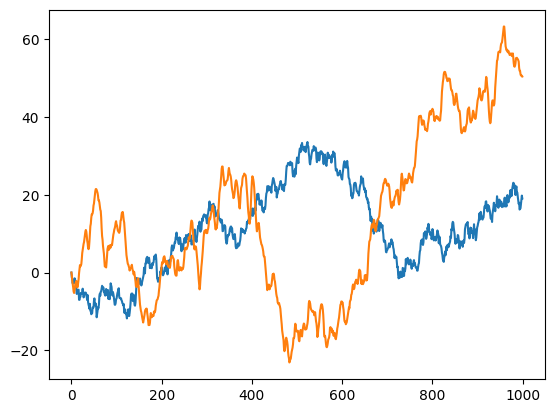

In [166]:
plt.plot(x_rw[0, :, 0])
plt.plot(x_sim[0, ::N, 0])